# Shot Noise Sensitivity of LLO in different units, and thoughts about LO phase noise.

This note book goes through the calculations required so that one can investigate how to transform a shot noise level for a DC laser power (in units of W/sqrt(Hz)) into an equivalent strain noise, and uses LLO aLIGO as an example. The reason for doing this is to see how the calculation works before applying it to A+ (which I either need to model or find a model of), since this is already well understood. Sometimes its easier to understand how the interferometer works if you use different units. To see how sensitive it is to gravitational waves its best to describe it with strain units; to see how its sensitive to mirror motion its best to think about it in terms of distance units. When thinking about it in terms of local oscillator phase noise, its best described in phase units. Being able to calculate how shot noise (determined by DC light level) at the AS port of aLIGO corresponds to an equivalent differential arm signal, you can work all of these things out. 

To begin this calculation, you need to know the interferometers response to differential arm motion. Since aLIGO is quite complicated, I modified the finesse file for LLO (from DCC T1300901-v5) to compute this. This finesse file contains (I believe) an accurate description of the LLO interferometer configured for aLIGO. By measuring the linear response function between a modulation of the 'phase' of ETMX to the a modulation of the intensity at the ouput of the OMC, one finds the relationship between differential arm motion and intensity, in units of Watts/rad. To compute this with finesse I first created a modulation for the ETMX mirrors phase:
```
fsig sig1 ETMXHR 300 0
```
To detect this modulation, I put a photodiode at the transmitted light from the OMC:
```
pd1 P_DC_OMC_probe 300 nOMC_HROC_trans
```
This command gives the photodiode 1 demodulation frequency (which I set to 300, the same frequency as for the modulation of the ETMC).

The modulation frequency of ETMX was then swept over with the xaxis command:
```
xaxis sig1 f log 1 10000 1000
```
and the photodiodes demodulation frequency was changed to be the x axis frequency:
```
put P_DC_OMC_probe f1 $x1
```
This allows for linear response functions to be measured.

Running this finesse code gives you a magnitude in units power/rad, so to convert a shot noise in power units to something with units of phase, you need to invert the linear response function generated by finesse. Multiplying the inverted linear response function by the shot noise spectrum (determined by the DC power) gives the phase that is equivalent to shot noise. As a check, this phase can then be converted to metres, and to strain (and I think it works out? Need to check for sqrt(2) maybe?). This should match the region where LIGOs sensitivity is limited by shot noise. This means that if you measure shot noise limited on the photodiode (flat), you are measuring a strain noise of the design curve. Below a certain frequency, the signal starts being dominated by things which arn't shot noise, such as radiation pressure and mirror coating noise. Below this frequency, the requirement to measure shot noise is relaxed.

Following this reasoning, if you are shot noise limited in A+, you are measuring the design curve of A+ at that frequency you measure at. 

The target for the local oscillator phase noise is to be ten times below the sensitivity curve for A+. What this means is that the output signal of the interferometer is dominated by the shot noise of the light (100mW) above a certain frequency. Below this frequency, the interfometer is dominated by radiation pressure noise. On a photodiode, this signal looks like a a flat spectrum and a 1/f^2 (guess) slope at low frequencys. The phase noise should be less than all of this noises. In power units, shot noise has variance of size $\frac{\hbar\omega}{4}$. In power units, the motion of a mirror with angle of incidence 45 degree has variance $\left(\frac{\omega}{c}\right)^2P\Delta^2x$, where $P$ is the power and $\Delta^2x$ is the variance of the motion. For balanced homodyne detection (with homodyne phase at $\pi/2$), the equation that determines if your local oscillator phase noise is good enough is ([https://doi.org/10.1103/PhysRevD.92.072009](https://doi.org/10.1103/PhysRevD.92.072009)):

$$
\Delta^2i_- = 4P_{\rm{LO}}\Delta^2 X^{\rm{sig}}_2 + 4P_{\rm{sig}}\Delta^2 X^{\rm{LO}}_2 
$$

Where:

$$
\\
P_{\rm{LO}} = \text{Local oscillator beam power}\\
P_{\rm{sig}} = \text{signal beam power}\\
\Delta^2 X^{\rm{LO}}_2 = \text{Noise variance of signal in the local oscillator beam}\\
\Delta^2 X^{\rm{sig}}_2 = \text{Noise variance of signal in the signal beam}
$$

Another less confusing way to look at this problem: if the noise curve of A+ is $s(f)$ i.e the smallest signal, the equivalent signal from a mirror in the LO path is 
$$
\frac{\omega}{c}\sqrt{P_{\rm{LO}}}x(f) = s(f)
$$
To get something in $m/\sqrt{Hz}$ units
$$
x(f) = \frac{c}{\omega\sqrt{P_{\rm{LO}}}}s(f)
$$
I think this works?

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from pykat import finesse
from pykat.detectors import *
from pykat.components import *
from pykat.commands import *
from pykat.structs import *

In [6]:
code_LLO = """
#--------------------------------------------------------------------------
# LLO_IFO_maxtem2.kat
#
# FINESSE kat file for the mode-matched L1 dual recycled Michelson with FP arm cavities.
#
# Design 2 refers to the updates from the original design, such as 
# including measured mirror parameters. Some lengths may have changed 
# from the original design to account for the new mirror parameters.
# Lengths are taken from E1200274.
# 
# No IMC or PMMT, thin PRM and SRM
#
# Mirror specs taken from https://nebula.ligo.caltech.edu/optics/ as of 2015/09/08
#
# IMC, HAM2, HAM6, OMC path and OMC are based on the generic aLIGO design files found here:
# https://dcc.ligo.org/L1300231-v10
# with updates based on galaxy page where appropriate.
#
# Thermal lens in ITMs modelled as a thin lens in front of the AR surfaces
# ITMs include non-thermal substrate lenses as calculated from measurements 
# reported in the polisher's reports found on the nebula page. These are turned 
# off by default here though.
#
# ** Updated non-thermal lens focal lengths (not used here though)**
# ITMY lens focal length = -82.4km
# ITMX lens focal length = 305km
# Calculation is shown in LIGO T1300954
#
# - Updated with Galaxy page(https://galaxy.ligo.caltech.edu/optics/) values for installed SRM-w
# - Includes locks for DARM (~10pm offset), PRCL, MICH, CARM and SRCL
#
# Charlotte Bond, Paul Fulda, Daniel Brown, Antonio Perreca, Andreas Freise 2015-09-08
#--------------------------------------------------------------------------

%%% FTblock laser
###########################################################################

l L0 125 0 n0
s lmod1 1 n0 n1
mod mod1 $f1 0.18 1 pm n1 n2
s lmod2 1 n2 n3
mod mod2 $f2 0.18 1 pm n3 n4
s lmod3 1 n4 n5
mod mod3 $f3 0.1 1 pm n5 n6
s mod3toMC1 1 n6 nMC1AR1in

###########################################################################
%%% FTend laser

%%% FTblock IMC
#####################################################################################

 # MC1 IMCF-01
bs2 MC1AR1 343u 6.849u 0 44.59 nMC1AR1in dump nMC1AR1trans dump
s sMC1substrate1 0.0845 $nsilica nMC1AR1trans nMC1HRin
bs1 MC1HR 6150u 0.7u 0 28.9661 nMC1HRin nMC1HRrefl nMC1HRtrans nMC1HRfromMC3HR 
s sMC1substrate2 0.0845 $nsilica nMC1HRrefl nMC1AR2in
bs2 MC1AR2 343u 6.849u 0 28.9661 nMC1AR2in dump nMCREFL dump
s sMC1HRtoMC2 16.2405708 nMC1HRtrans nMC2in 

# MC2 IMCC-03
bs1 MC2 3.5u 12.5u 0 0.82 nMC2in nMC2refl nMC2trans dump1
s sMC2toMC3 16.2405708 nMC2refl nMC3in 
attr MC2 Rc 27.178

# MC3 IMCF-02 
bs1 MC3HR 6130u 0.7u 0 44.59 nMC3in nMC3refl nMC3trans nMCreturn_refl
s sMC3toMC1 0.465 nMC3refl nMC1HRfromMC3HR

s sMC3substrate 0.0845 $nsilica nMC3trans nMC3ARin
bs2 MC3AR 305u 6.85u 0 28.9661 nMC3ARin dump nMC3ARtrans dump
s sMC3ARtoIM1 0.4282 nMC3ARtrans nIM1in

#####################################################################################
%%% FTend IMC

%%% FTblock HAM2
#####################################################################################

# IM1 a.k.a. SM1
bs1 IM1 0 0 0 53 nIM1in nIM1refl nIM1HRtrans dump
s sIM1sub 0.02995 $nsilica nIM1HRtrans nIM1ARin
bs2 IM1AR 0 0 0 33.4 nIM1ARin dump5 nIM1ARtrans dump

s IM1ARtonanoscan 3 nIM1ARtrans nIOT2Lnanoscan

#AOE1
s sIM1toAOE1 0.1955 nIM1refl nAOE1in
lens AOE1 inf nAOE1in nAOE1trans

# IM2 a.k.a. PMMT1 
s sAOE1toIM2 1.0983 nAOE1trans nIM2in
bs1 IM2 0 0 0 7 nIM2in nIM2refl dump dump
attr IM2 Rc 12.8 

s sIM2toIM3 1.1704 nIM2refl nIM3in

# IM3 a.k.a PMMT2
#s sIM2toIM3 1.1704 nIM2refl nIM3in
bs1 IM3 0 0 0 7.1 nIM3in nIM3refl dump dump
attr IM3 Rc -6.24

#AOE2
s sIM3toAOE2 1.041 nIM3refl nAOE2in
lens AOE2 inf nAOE2in nAOE2trans

# IM4 a.k.a. SM2
s sAOE2toIM4 0.134 nAOE2trans nIM4in

bs1 IM4 2400u 0 0 45 nIM4in nIM4refl nIM4trans nIM4rettrans
s sIM4toPRMAR 0.4135 nIM4refl nREFL

#####################################################################################
%%% FTend HAM2

%%% FTblock PR
###########################################################################

# PRM PRM-02

# AR surface
m2 PRMAR 26u 11.45u $phi_PRM nREFL nPRMARb
#m2 PRMAR 0 40u $phi_PRM nREFL nPRMARb

# Substrate
s sPRMsub1 0.0737 $nsilica nPRMARb nPRMHRa

# HR surface
m1 PRMHR 0.031 5.9u $phi_PRM nPRMHRa nPRMHRb
#m1 PRMHR 0.03 8.5u $phi_PRM nPRMHRa nPRMHRb
attr PRMHR Rc 11.009

# Distance between PRM and PR2
s lp1 16.6107 nPRMHRb nPR2a

# PR2 PR2-02
bs1 PR2 243u 8.6u 0 -0.79 nPR2a nPR2b nPOP dump
#bs1 PR2 250u $Mloss 0 -0.79 nPR2a nPR2b nPOP dump
attr PR2 Rc -4.545

# Distance from PR2 to PR3
s lp2 16.1647 nPR2b nPR3a
 	
# PR3 PR3-03
bs1 PR3 5.3u 17u 0 0.615 nPR3a nPR3b dump dump
#bs1 PR3 0 $Mloss 0 0.615 nPR3a nPR3b dump dump
attr PR3 Rc 36.027

# Distance from PR3 to BS
s lp3 19.5381 nPR3b nPRBS

###########################################################################
%%% FTend PR


%%% FTblock BS
###########################################################################

# BS beamsplitter
##------------------------------------------------------------ 
## BS 
##                             ^ 
##                  to IMY     |      
##                             |      ,'-.
##                             |     +    `. 
##                        nYBS |   ,'       :'
##      nPR3b                  |  +i1      +
##         ---------------->    ,:._  i2 ,'
##    from the PRC       nPRBS + \  `-. + nXBS
##                           ,' i3\   ,' --------------->
##                          +      \ +     to IMX
##                        ,'     i4.'
##                       `._      ..
##                          `._ ,' |nSRBS
##                             -   |
##                                 |to the SRC
##                                 |
##                                 v
##------------------------------------------------------------

# BS BS-02
bs1 BS 0.5 8.6u $phi_BS 45 nPRBS nYBS nBSi1 nBSi3
#bs1 BS 0.5 $Mloss $phi_BS 45 nPRBS nYBS nBSi1 nBSi3
s BSsub1 0.0685 $nsilica nBSi1 nBSi2
s BSsub2 0.0684 $nsilica nBSi3 nBSi4
bs2 BSAR1 30u 1.7u $phi_BS -29.1951 nBSi2 dump nXBS nPOX
#bs2 BSAR1 50u 0 0 -29.195 nBSi2 dump14 nXBS nPOX
bs2 BSAR2 30u 1.7u $phi_BS 29.1951 nBSi4 dump nSRBS dump
#bs2 BSAR2 50u 0 0 29.195 nBSi4 dump15 nSRBS dump16
###########################################################################
%%% FTend BS

%%% FTblock Yarm
###########################################################################

s ly1 4.847 nYBS nCPYAR1a

# Y arm compensation plate CP-08
m2 CPYar1 48.9u 0.4u 0 nCPYAR1a nCPYAR1b
s sCPY 0.10032 $nsilica nCPYAR1b nCPYAR2a
m2 CPYar2 30.5u 0.3u 0 nCPYAR2a nCPYAR2b
s sCPYtoITMYar 0.02 nCPYAR2b nITMYTLa

# Y arm input mirror ITM-08
# Thermal lens
lens ITMYTL $TL_f nITMYTLa nITMYTLb
s ITMYTL_null 0 nITMYTLb nITMYconstLa

# Constant ITMY substrate lens
lens ITMYconstL inf nITMYconstLa nITMYconstLb
s ITMYTL_null2 0 nITMYconstLb nITMY1

m2 ITMYAR 250u 0.6u $phi_ITMY nITMY1 nITMYs1
#m2 ITMYAR 0 20u 0 nITMY1 nITMYs1
s lITMY 0.19961 $nsilica nITMYs1 nITMYs2

m1 ITMYHR 0.0148 14.3u $phi_ITMY nITMYs2 nITMY2
#m1 ITMYHR 0.014 $Mloss $phi_ITMY nITMYs2 nITMY2
attr ITMYHR Rc -1940.7

# Y-arm
s LYarm 3994.515 nITMY2 nETMY1

# ETMY ETM-09
m1 ETMYHR 3.5u  9.3u $phi_ETMY nETMY1 nETMYs1
#m1 ETMYHR 5u $Mloss $phi_ETMY nETMY1 nETMYs1
s ETMYsub 0.2 $nsilica nETMYs1 nETMYs2
m2 ETMYAR 230u 0 $phi_ETMY nETMYs2 nPTY
#m2 ETMYAR 0 500u 0 nETMYs2 nPTY

attr ETMYHR Rc 2242.4

attr ETMYHR mass 40
attr ITMYHR mass 40

###########################################################################
%%% FTend Yarm

%%% FTblock Xarm
###########################################################################

s lx1 4.829 nXBS nCPXAR1a

# X arm compensation plate CP-06
m2 CPXar1 33u 0.6u 0 nCPXAR1a nCPXAR1b
s sCPX 0.10031 $nsilica nCPXAR1b nCPXAR2a
m2 CPXar2 8u 0.6u 0 nCPXAR2a nCPXAR2b
s sCPXtoITMXar 0.02 nCPXAR2b nITMXTLa

# X arm input mirror ITM-04
# Thermal lens
lens ITMXTL $TL_f nITMXTLa nITMXTLb
s ITMXtl_null 0 nITMXTLb nITMXconstLa

# Non-thermal ITM lens
lens ITMXconstL inf nITMXconstLa nITMXconstLb

s ITMXTL_null2 0 nITMXconstLb nITMX1
m2 ITMXAR 164u 0.5u $phi_ITMX nITMX1 nITMXs1
#m2 ITMXAR 0 20u 0 nITMX1 nITMXs1
s ITMXsub 0.20027 $nsilica nITMXs1 nITMXs2

m1 ITMXHR 0.0148 10.4u $phi_ITMX nITMXs2 nITMX2
#m1 ITMXHR 0.014 $Mloss $phi_ITMX nITMXs2 nITMX2

# X-arm
s Lx 3994.485 nITMX2 nETMX1

# ETMX ETM-07
m1 ETMXHR 3.7u 10.9u $phi_ETMX nETMX1 nETMXs1
#m1 ETMXHR 5u $Mloss $phi_ETMX nETMX1 nETMXs1
s ETMXsub 0.2 $nsilica nETMXs1 nETMXs2
m2 ETMXAR 200u 0 $phi_ETMX nETMXs2 nPTX
#m2 ETMXAR 0 500u 0 nETMXs2 nPTX

attr ITMXHR Rc -1937.9
attr ETMXHR Rc 2239.7

attr ITMXHR mass 40
attr ETMXHR mass 40

###########################################################################
%%% FTend Xarm

%%% FTblock SR
###########################################################################

# Distance from BS to SR3
s ls3 19.3661 nSRBS nSR3b

# SR3 SR3-01
bs1 SR3 5u 19.1u 0 0.785 nSR3b nSR3a dump dump
#bs1 SR3 0 $Mloss 0 0.785 nSR3b nSR3a dump dump
attr SR3 Rc 35.97

# Distance from SR3 to SR2
s ls2 15.4435 nSR3a nSR2b

# SR2 SR2-04
bs1 SR2 18.3u 6.1u 0 0.87 nSR2b nSR2a dump dump
#bs1 SR2 0 $Mloss 0 -0.87 nSR2b nSR2a dump dump
attr SR2 Rc -6.406

# Distance from SR2 to SRMHR
s ls1 15.7566 nSR2a nSRMHRa

# Signal recycling mirror SRM-w14
m1 SRMHR 0.3688 8.3u $phi_SRM nSRMHRa nSRMHRb
#m1 SRMHR 0.32 8.7u $phi_SRM nSRMHRa nSRMHRb

s SRMsub 0.0749 $nsilica nSRMHRb nSRMARa
m2 SRMAR 50u 0 $phi_SRM nSRMARa nSRMARb
#m2 SRMAR 0 50n 0 nSRMARa nSRMARb
attr SRMHR Rc -5.715

###########################################################################
%%% FTend SR

%%% FTblock FI
###########################################################################
# The FI is on a platform delimited by the Input/Output Buffer Assy (I/OBA)
# The physical distance IBA --> OBA = 0.5034 (D0901920-V13)
# OFI design based on: D0900464, D1002598

# Distance from SRM (AR surface) to the input buffle assy (IBA) in OFI sus
s lIBAin 0.491516 nSRMARb nIBAin
m1 IBA 1 0 0 nIBAin nIBAout

# Distance from IBA to input of OFI (Prism in between not considered)
s lOFIin 0.16 nIBAout nOFIin

# Input Polirizer IP (Silica)
bs1 IP 1 0 0 0 nOFIin dump nIPtrans dump
s lIP 0.019 $nsilica nIPtrans nROTin

# Rotator (TGG)
m1 ROTin 1 0 0 nROTin nROTb
s lROT 0.08285 $nTGG nROTb nROTouta
m1 ROTout 1 0 0 nROTouta nOPa

# Output polirizer OP (Silica)
s lOP 0.019 $nsilica nOPa nOPb
m1 OP 1 0 0 nOPb nOFIout

# Waveplate thickness 
s lWP 0.0127 $nCalcite nOFIout nWPa
m1 WP 1 0 0 nWPa nWPb

# Distance from Waveplate to OBA of OFI (Prism in between not considered)
s lOBA 0.2098563 nWPb nOBAin
m1 OBA 1 0 0 nOBAin nOBAout
###########################################################################
%%% FTend FI

%%% FTblock OMCpath
###########################################################################
# (Loctions and angles based on the solid work file D1000342-v14 give ~5% 
# mismatch. Thus lom1, lom3omc have been adjusted to get ~99.7% overlap at the OMC)
# (lom1=2.6334,lom3omc=0.24.8 give 99% overlap at OMC)

# Distance OBA --> OM1  
s lom1 2.724 nOBAout nOM1a 

#OM1
bs1 OM1 800u $Mloss 0 2.251 nOM1a nOM1b dump dump # T is set for high power; Loss is a guess
attr OM1 Rc 4.6

# Distance OM1 --> OM2
s lom2 1.395 nOM1b nOM2a 

# OM2
bs1 OM2 10u $Mloss 0 4.399 nOM2a nOM2b dump dump  # T is a guess
attr OM2 Rc 1.7058

# Distance OM2 --> OM3
s lom3 0.631 nOM2b nOM3a 
bs1 OM3 0.01 $Mloss 0 30.037 nOM3a nOM3b nOM3trans dump # T is a from T1200410-v2

# Distance OM3 --> OMC input coupler IC (AR side)
s lom3omc 0.196 nOM3b nOMC_ARIC_in # By design should be ~0.31

#  Distance in transmission to OM3 used for testing
#s lomOM3trans 0.1 nOM3trans nOMC_ARIC2_in

###########################################################################
%%% FTend OMCpath 

%%% FTblock OMC
###########################################################################
# OMC (as built parameters: D1300507-v1)

# Input Coupler IC (flat mirror)
bs1 OMC_ARIC 1 0 0 4.004 nOMC_ARIC_in dump nOMC_ARIC_trans dump
s subOMC_IC 0.01078 $nsilica nOMC_ARIC_trans nOMC_HRIC_in
bs1 OMC_HRIC 0.0076 10u 0 2.7609 nOMC_HRIC_in dump nOMC_HRIC_trans nOMC_HRIC_ret
# Distance from IC to OC 
s OMC_ICOC 0.2815 1 nOMC_HRIC_trans nOMC_HROC_in

# Output Coupler OC (flat mirror)
bs1 OMC_HROC 0.0075 10u 0 4.004 nOMC_HROC_in nOMC_HROC_refl nOMC_HROC_trans nOMC_HROC_ret
s subOMC_OC 0.01078 $nsilica nOMC_HROC_trans nOMC_AROC_in
bs1 OMC_AROC 1 0 0 2.7609 nOMC_AROC_in dump nOMC_AROC_trans dump
# Distance from OC to CM1
s OMC_OCCM1 0.2842 1 nOMC_HROC_refl nOMC_CM1_in

# Curved Mirror CM1
bs1 OMC_CM1 36u 10u 0 4.004 nOMC_CM1_in nOMC_CM1_refl dump dump

# Distance from CM1 to CM2 
s OMC_CM1CM2 0.2815 1 nOMC_CM1_refl nOMC_CM2_in
attr OMC_CM1 Rc 2.57321

# Curved Mirror CM2
bs1 OMC_CM2 35.9u 10u 0 4.004 nOMC_CM2_in nOMC_CM2_refl dump dump
attr OMC_CM2 Rc 2.57369

# Distance from CM2 to IC 
s CM2OC 0.2842 1 nOMC_CM2_refl nOMC_HRIC_ret

###########################################################################
%%% FTend OMC

%%% FTblock tunings
###########################################################################

const phi_SRM 89.9989780433498
const phi_PRM -0.00104420144479276
const phi_ITMX 0.000561571624295843
const phi_ITMY -0.000561571624295843
const phi_ETMX 0.00179545319662242
const phi_ETMY -0.00184678655646107
const phi_BS 0

###########################################################################
%%% FTend tunings

%%% FTblock constants
###########################################################################

const nsilica 1.44963098985906
const nTGG 1.954
const nCalcite 1.65846
const Mloss 37.5u
const DARM_DC_offset 0.147303
const TL_f 34.5k
const f1 9099055
const mf1 9099055
const f2 45495275
const mf2 -45495275
const f3 24000000
const nf3 -24000000
const fM 36397884
const nfM -36397884

###########################################################################
%%% FTend constants

%%% FTblock errsigs
###########################################################################

pd1 REFL_f1_I $f1 105 nREFL
#pd1 REFL_f1_Q $f1 15 nREFL
pd1 REFL_f2_I $f2 30 nREFL
#pd1 REFL_f2_Q $f2 120 nREFL
pd1 POP_f1_I $f1 116 nPOP
#pd1 POP_f1_Q $f1 26 nPOP
#pd1 POP_f2_I $f2 28 nPOP
pd1 POP_f2_Q $f2 118 nPOP
#pd1 AS_f1_I $f1 0 nSRMARb
#pd1 AS_f1_Q $f1 90 nSRMARb
#pd1 AS_f2_I $f2 130 nSRMARb
#pd1 AS_f2_Q $f2 40 nSRMARb

noplot REFL_f1_I
noplot REFL_f2_I
noplot POP_f1_I
noplot POP_f2_Q


###########################################################################
%%% FTend errsigs

%%% FTblock powers
###########################################################################

#pd P_DC_AS  nSRMARb
pd P_DC_OMC nOMC_HROC_trans
pd1 P_DC_OMC_probe 300 nOMC_HROC_trans
#pd PIMCtrans nREFL*
#pd Px nITMX2
#pd Py nITMY2
#pd Pprc nPRMHRb
#pd Psrc nSRMHRa*

#noplot P_DC_OMC

#ad prc0 0 nPRMHRb
#ad prcf1 $f1 nPRMHRb
#ad prcf2 $f2 nPRMHRb
#ad aoc0 0 nOMC_HROC_trans
#ad asc0 0 nSRMARb
#ad asf1 $f1 nSRMARb
#ad asf2 $f2 nSRMARb
#ad src0 0 nSRMHRa*
#ad srcf1 $f1 nSRMHRa*
#ad srcf2 $f2 nSRMHRa*
#ad1 A_DC_OMC_probe 300 nOMC_HROC_trans

###########################################################################
%%% FTend powers

%%% FTblock HOMs
###########################################################################

cav cavIMC MC2 nMC2in MC2 nMC2refl 
cav cavPRX PRMHR nPRMHRb ITMXHR nITMXs2
cav cavPRY PRMHR nPRMHRb ITMYHR nITMYs2
cav cavSRX SRMHR nSRMHRa ITMXHR nITMXs2
cav cavSRY SRMHR nSRMHRa ITMYHR nITMYs2
cav cavXARM ITMXHR nITMX2 ETMXHR nETMX1
cav cavYARM ITMYHR nITMY2 ETMYHR nETMY1
cav cavOMC OMC_HROC nOMC_HROC_refl OMC_HROC nOMC_HROC_in  

maxtem 2

###########################################################################
%%% FTend HOMs

%%% FTblock locks
###########################################################################

set PRCL_err POP_f1_I  re
set MICH_err POP_f2_Q  re
set CARM_err REFL_f1_I re
set SRCL_err REFL_f2_I re
#set AS_f2_I_re AS_f2_I re
set OMC_DC P_DC_OMC re

func DARM_err = $OMC_DC - $DARM_DC_offset

lock PRCL_lock $PRCL_err -5.18068339474 10u
lock MICH_lock $MICH_err 9.61838881033 10u
lock CARM_lock $CARM_err 6.68149947611e-05 10u
lock DARM_lock $DARM_err -0.00427435126487 1u
lock SRCL_lock $SRCL_err -1.18255618416 10u


func mMICH_lock = 0 - $MICH_lock
func ETMX_lock = $CARM_lock + $MICH_lock + $DARM_lock
func ETMY_lock = $CARM_lock - $MICH_lock - $DARM_lock

put* PRMHR   phi     $PRCL_lock
put* PRMAR   phi     $PRCL_lock

put* ITMXHR  phi     $MICH_lock
put* ITMXAR  phi     $MICH_lock
put* ITMYHR  phi     $mMICH_lock
put* ITMYAR  phi     $mMICH_lock

put* ETMXHR  phi     $ETMX_lock
put* ETMXAR  phi     $ETMX_lock

put* ETMYHR  phi     $ETMY_lock
put* ETMYAR  phi     $ETMY_lock

put* SRMHR   phi     $SRCL_lock
put* SRMAR   phi     $SRCL_lock

noplot PRCL_lock
noplot SRCL_lock
noplot MICH_lock
noplot DARM_lock
noplot CARM_lock
noplot mMICH_lock
noplot ETMX_lock
noplot ETMY_lock

###########################################################################
%%% FTend locks

%%% FTblock ASWFSs
###########################################################################

s lOM3trans2ASWFSBS 0.66 nOM3trans nASWFSBSin 
bs ASWFSBS 0.5 0.5 0 45 nASWFSBSin nASWFSBSrefl nASWFSBStrans dump

s lASWFSBS2ASWFSA 0.1 nASWFSBSrefl nASWFSA
attr lASWFSBS2ASWFSA gouy 70

s lASWFSBS2ASWFSB 0.379 nASWFSBStrans nASWFSB
attr lASWFSBS2ASWFSB gouy 160

# AS WFS RF detectors
#pd1 ASWFSA_45I_P $f2 0 nASWFSA 
#pd1 ASWFSA_45Q_P $f2 90 nASWFSA 
#pd1 ASWFSA_36I_P $fM 15 nASWFSA 
#pd1 ASWFSA_36Q_P $fM 75 nASWFSA 
#pdtype ASWFSA_45I_P y-split
#pdtype ASWFSA_45Q_P y-split
#pdtype ASWFSA_36I_P y-split
#pdtype ASWFSA_36Q_P y-split

#pd1 ASWFSB_45I_P $f2 0 nASWFSB 
#pd1 ASWFSB_45Q_P $f2 90 nASWFSB 
#pd1 ASWFSB_36I_P $fM 65 nASWFSB 
#pd1 ASWFSB_36Q_P $fM 155 nASWFSB
#pdtype ASWFSB_45I_P y-split
#pdtype ASWFSB_45Q_P y-split
#pdtype ASWFSB_36I_P y-split
#pdtype ASWFSB_36Q_P y-split

const f_sig 1 

# AS WFS RF detectors double demodulated at signal frequency $f_sig
#pd2 ASWFSA_45I_audio_P $f2 0 $f_sig max nASWFSA 
#pd2 ASWFSA_45Q_audio_P $f2 90 $f_sig max nASWFSA 
#pd2 ASWFSA_36I_audio_P $fM 0 $f_sig max nASWFSA 
#pd2 ASWFSA_36Q_audio_P $fM 90 $f_sig max nASWFSA 
#pdtype ASWFSA_45I_audio_P y-split
#pdtype ASWFSA_45Q_audio_P y-split
#pdtype ASWFSA_36I_audio_P y-split
#pdtype ASWFSA_36Q_audio_P y-split

#pd2 ASWFSB_45I_audio_P $f2 0 $f_sig max nASWFSB 
#pd2 ASWFSB_45Q_audio_P $f2 90 $f_sig max nASWFSB 
#pd2 ASWFSB_36I_audio_P $fM 0 $f_sig max nASWFSB 
#pd2 ASWFSB_36Q_audio_P $fM 90 $f_sig max nASWFSB
#pdtype ASWFSB_45I_audio_P y-split
#pdtype ASWFSB_45Q_audio_P y-split
#pdtype ASWFSB_36I_audio_P y-split
#pdtype ASWFSB_36Q_audio_P y-split

###########################################################################
%%% FTend ASWFSs

%%% FTblock commands
%%% FTend commands

noplot DARM_err

var f2 1


# to create differential arm motion, you need to use fsig. Only one signal
# can be used in a calculation, but the same frequency can be fed to 
# different components. By having them out of phase, this creates a 
# differential signal. Changing the frequnecy of f1 with the xaxis
# updates the signal for both sig 1 and sig2

fsig sig1 ETMXHR 1 0
fsig sig2 ETMYHR 1 180

xaxis sig1 f log 5 5000 2999

put P_DC_OMC_probe f1 $x1

#put A_DC_OMC_probe f1 $x1


yaxis abs:deg
"""
kat_LLO = finesse.kat()

# Currently the kat object is empty. We can fill it using a block
# string of normal FINESSE commands by parsing them.
kat_LLO.parse(code_LLO)

# Once we have some simulation built up we can run it simply by calling...
out_LLO = kat_LLO.run()


Parsing `set PRCL_err POP_f1_I re` into pykat object not implemented yet, added as extra line.
Parsing `set MICH_err POP_f2_Q re` into pykat object not implemented yet, added as extra line.
Parsing `set CARM_err REFL_f1_I re` into pykat object not implemented yet, added as extra line.
Parsing `set SRCL_err REFL_f2_I re` into pykat object not implemented yet, added as extra line.
Parsing `set OMC_DC P_DC_OMC re` into pykat object not implemented yet, added as extra line.
--------------------------------------------------------------
Running kat - Started at 2021-03-22 12:25:45.315832


100% | ETA:  0:00:00 | Calculating - Locked ✓✓✓✓✓ (Locking steps tried 0/10000)

Used Finesse None at C:\Users\Joseph Briggs\OneDrive - University of Glasgow\Documents\kat-2.3.1-win_64bit\Finesse\kat.exe

Finished in 68.9092 seconds


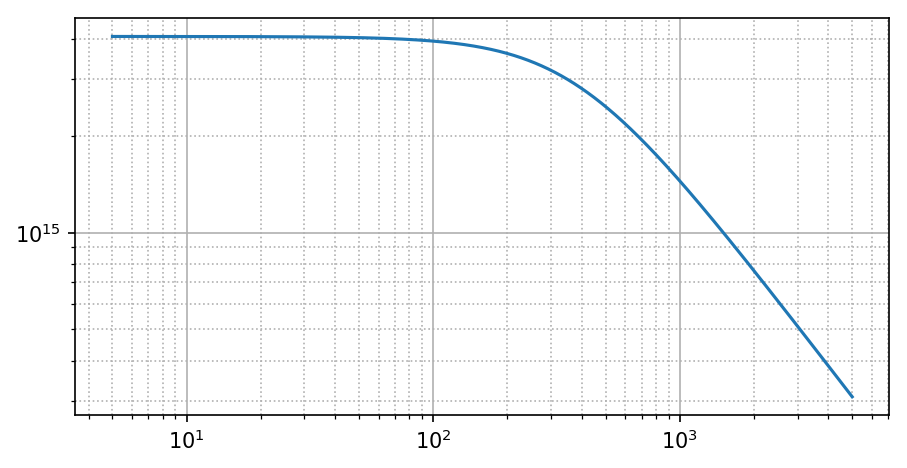

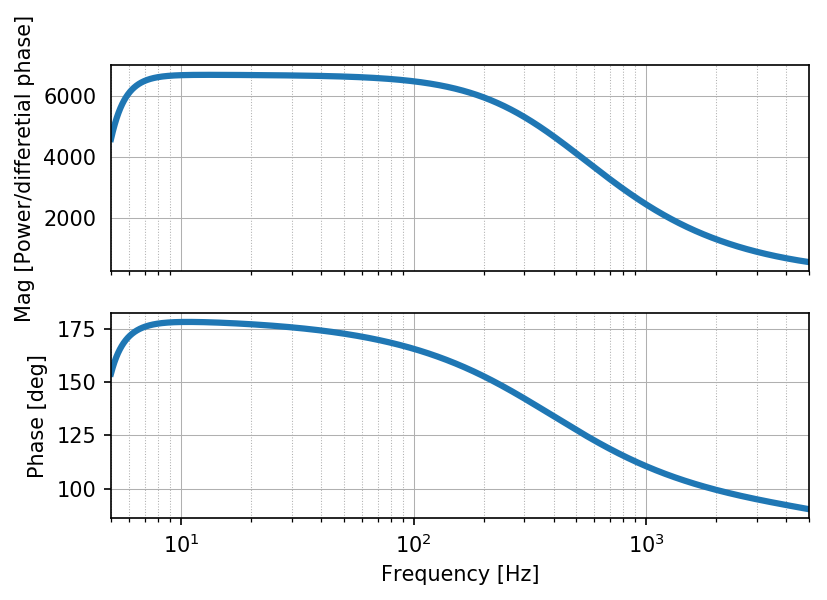

In [7]:
# We can plot the output simply enough using pylab plotting.
#foo= out.plot()

#need to divide response by 2, since the mirrors where differential moved by amount of 2 times modulation size

response = np.abs(out_LLO['P_DC_OMC_probe'])/2

detector_response = np.array([out_LLO.x,out_LLO['P_DC_OMC_probe']])
np.savetxt("detector_response.csv",detector_response,delimiter=",")

golden_ratio = 1.682;
b = 2.5
a = b*golden_ratio

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (a+b,a)
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['grid.linewidth'] = 0.5
#plt.rcParams['grid.linestyle'] = ':'

#blue = tuple(np.array([114,158,206])/256)
#red = tuple(np.array([237,102,93])/256)


fig, axs = plt.subplots(2,1,sharex = True,figsize = (6,4))
axs[0].semilogx(out_LLO.x,response, color = 'tab:blue')
#axs[0].semilogx(out_LHO.x[100:-1],response_LHO[100:-1], color = red)
axs[0].grid(b=True, which='major' , linestyle='-')
axs[0].grid(b=True, which='minor', linestyle=':')
axs[0].autoscale(enable=True, axis='x', tight=True)
axs[0].set_ylabel('Mag [Power/differetial phase]')
axs[0].tick_params(top= False, bottom= False , left=False, right=False, labelleft=True, labelbottom=False)


axs[1].semilogx(out_LLO.x,180/np.pi*np.angle(out_LLO['P_DC_OMC_probe']), color = 'tab:blue')
#axs[1].semilogx(out_LHO.x,180/np.pi*np.angle(out_LHO['P_DC_OMC_probe']), color = red)
axs[1].grid(b=True, which='major' , linestyle='-')
axs[1].grid(b=True, which='minor', linestyle=':')
axs[1].autoscale(enable=True, axis='x', tight=True)
axs[1].set_ylabel('Phase [deg]')
axs[1].set_xlabel('Frequency [Hz]')

#plt.savefig('response_L1.png')
#plt.savefig('response_L1.pdf')
plt.show()


## Calculation:

With the transfer function for differetial arm motion (in watt/phase) properly calibrated (above we needed to dived the response by 2 since the input modulation was effectively double since we modulated both mirrors), we can calculate the shot noise limit of the detector.

starting with the ASD for shot noise (units in $\frac{W}{\sqrt{Hz}})$:
$$
n_s(f) = \sqrt{\frac{2\pi \hbar c P_{LO}}{\lambda}}
$$
the equivalent noise in differential arm length is
$$
h(f) = \frac{n_s}{R(f)}
$$
where $R$ is the linear response function of the interferometer to differential arm signals. The units of $R$ depend on how you calculate it, I simulated the interferometers linear response function by applying a signal to ETMX, and a signal 180deg from the signal on ETMYX to ETMY
```
fsig sig1 ETMXHR 1 0
fsig sig2 ETMYHR 1 180
```
and measuring the light on the DC output of the OMC as the frequency was swept for the signal
```
xaxis sig1 f log 5 5000 2999

put P_DC_OMC_probe f1 $x1
```
Since the input modulation is essentially doubled since the mirrors move out of phase (eg, one mirror moves +phase, the other moves -phase, the differential motion is 2*phase), the response needs to be divided by 2.

Calculating the response function this way gives you a tranfer function in units of Power/(phase difference between two arms), so 
$$
h_\theta(f) = \frac{n_s}{R(f)}
$$
has units of (phase difference between the two arms)/sqrt(Hz).

To convert this to units of differential arm displacement, the phase needs to be converted to metres. Since the light is at normal incidence, an extra factor of 2 is needed (its as if the mirror moved twice as far, it goes distance x, bounces back and travels another distance x)
$$
h_m(f) = h(f)_\theta \frac{\lambda}{2\pi}2
$$
To convert this to strain, divide by the arm length (~4000m)
$$
h_s(f) = h(f)_\theta \frac{\lambda}{2\pi}\frac{1}{4000}
$$

If instead of starting with the shot noise of a photocurrent, you start with the noise curve $h_s(f)$ i.e. the design curve, you can work backwards to get the noise of a photocurrent.

0.147302900414


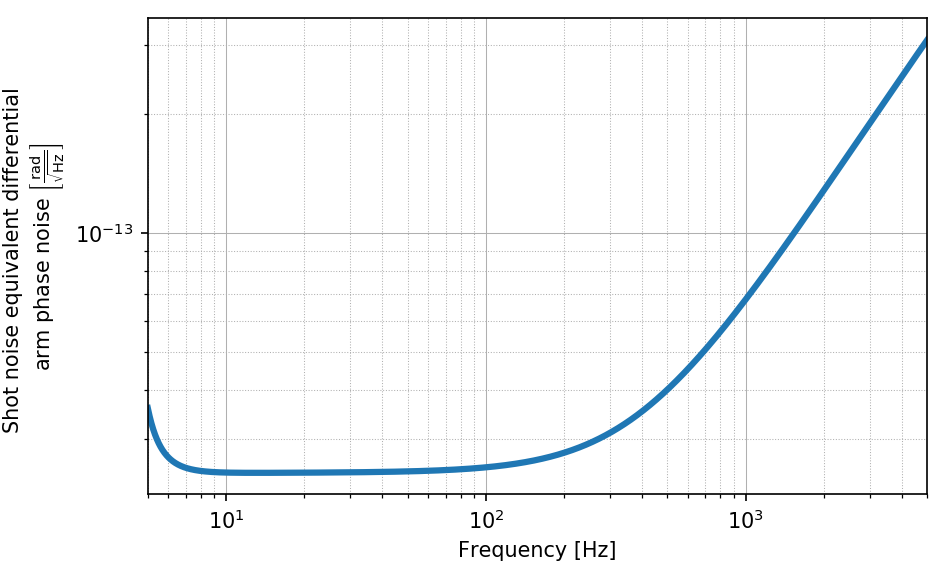

In [8]:
#Power of DC Photodiode 
frequency = out_LLO.x
P = np.abs(out_LLO['P_DC_OMC'][0])
print(P)

hbar = 1.05e-34
c = 3e8
wavelength = 1064e-9

shot_noise = np.squeeze(np.sqrt((2*np.pi*hbar*c*P/wavelength))*np.ones((1,len(response))))


DARM_shot_noise_limit_phase = shot_noise/response

plt.loglog(frequency,DARM_shot_noise_limit_phase, color = 'tab:blue')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.autoscale(enable=True, axis='x', tight=True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Shot noise equivalent differential \n'+ r'arm phase noise $\left[\frac{\rm{rad}}{\sqrt{\rm{Hz}}}\right]$')
plt.show()


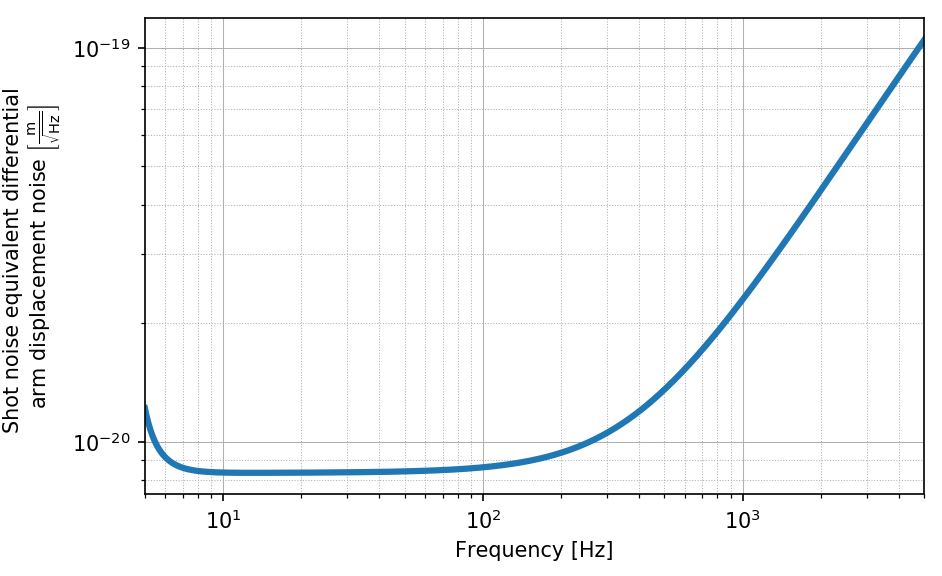

In [9]:
DARM_shot_noise_limit_phase_metres = DARM_shot_noise_limit_phase*wavelength/(np.pi)

plt.loglog(frequency,DARM_shot_noise_limit_phase_metres, color = 'tab:blue')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.autoscale(enable=True, axis='x', tight=True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Shot noise equivalent differential \n' + r'arm displacement noise $\left[\frac{\rm{m}}{\sqrt{\rm{Hz}}}\right]$')
plt.show()

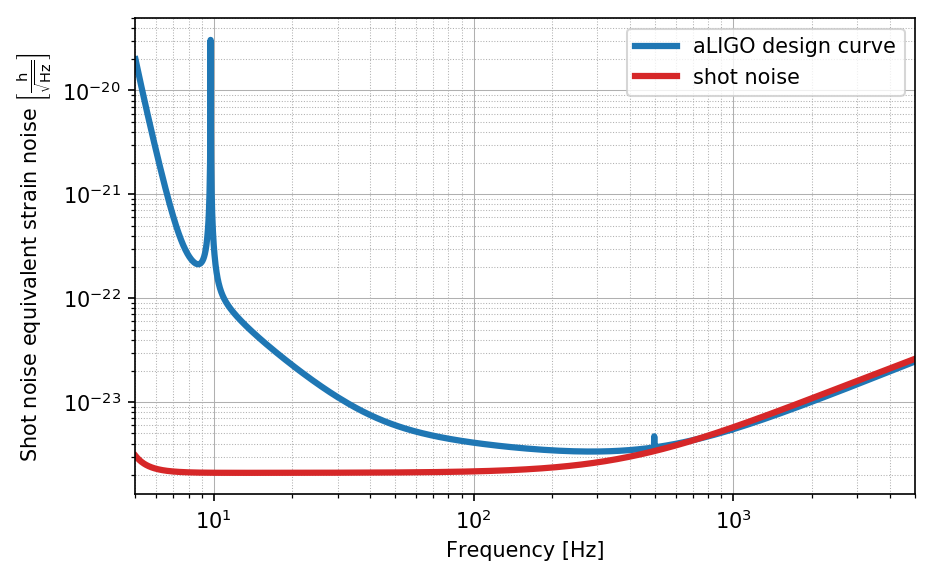

In [10]:
aligo_design = np.loadtxt('aligo_design_curve.txt')

#input file and finesse simulation use same frequency axis
aligo_design_curve = aligo_design[:,1]


DARM_shot_noise_limit_phase_strain = DARM_shot_noise_limit_phase_metres/(4000)

plt.loglog(frequency,aligo_design_curve,color = 'tab:blue')
plt.loglog(frequency,DARM_shot_noise_limit_phase_strain, color = 'tab:red')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.autoscale(enable=True, axis='x', tight=True)
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Shot noise equivalent strain noise $\left[\frac{\rm{h}}{\sqrt{\rm{Hz}}}\right]$')
plt.legend(['aLIGO design curve','shot noise'])
#plt.savefig('aligo_shot_noise_limit.png',bbox_inches = "tight")
#plt.savefig('aligo_shot_noise_limit.pdf',bbox_inches = "tight")
plt.show()


In [11]:
#aligo_design = np.loadtxt('aligo_design_curve.txt')

#input file and finesse simulation use same frequency axis
#aligo_design_curve = aligo_design[:,1]

#plt.loglog(frequency,aligo_design[:,1],aligo_design[:,0],aligo_design[:,1],'--')
#plt.grid(True)
#plt.autoscale(enable=True, axis='x', tight=True)
#plt.xlabel('Frequency [Hz]')
#plt.ylabel(r'Strain noise $\left[\frac{\rm{h}}{\sqrt{\rm{Hz}}}\right]$')
#plt.show()

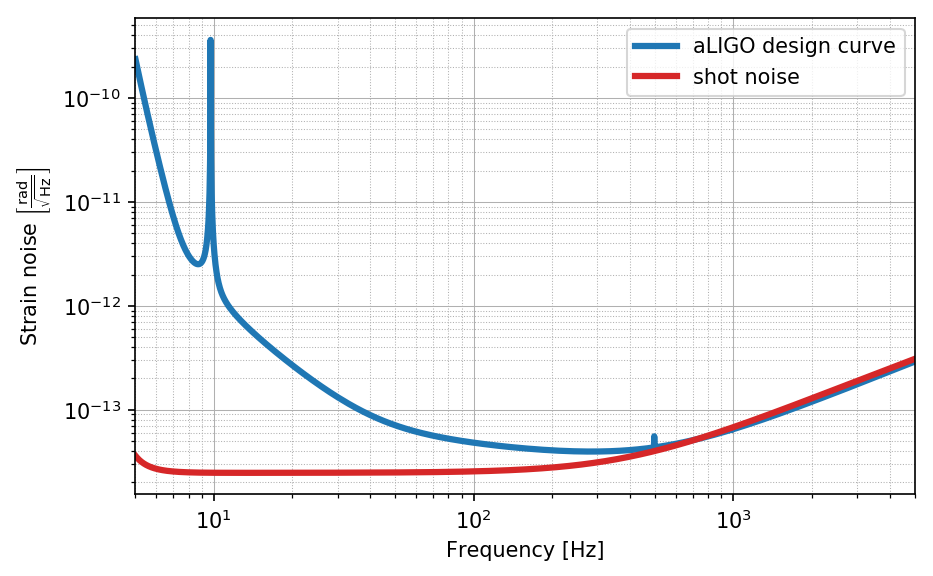

In [12]:
#convert to radians/sqrt(Hz) units

#*4000m to get from strain to metres
#*2 pi / lambda to get phase to m

aligo_design_curve_rad = aligo_design_curve*4000*np.pi/(wavelength)

plt.loglog(frequency,aligo_design_curve_rad,color = 'tab:blue')
plt.loglog(frequency,DARM_shot_noise_limit_phase,color = 'tab:red')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.autoscale(enable=True, axis='x', tight=True)
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Strain noise $\left[\frac{\rm{rad}}{\sqrt{\rm{Hz}}}\right]$')
plt.legend(['aLIGO design curve','shot noise'])
plt.show()

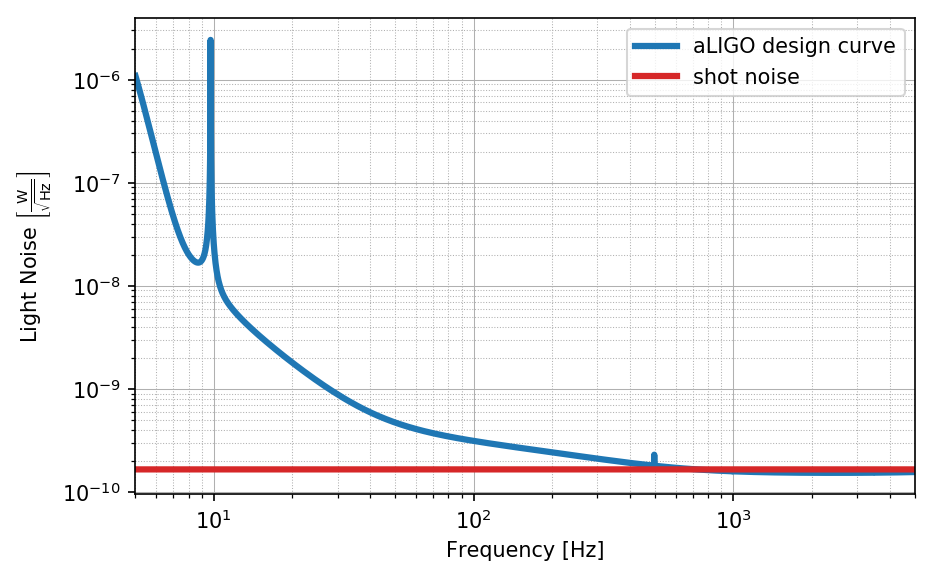

In [13]:
#create spectrum in units of power, with flat shot noise...
aligo_design_curve_light_noise = aligo_design_curve_rad*response

np.savetxt("lightnoiseligo.txt",np.vstack([frequency,aligo_design_curve_light_noise]), delimiter=',')

plt.loglog(frequency,aligo_design_curve_light_noise,color = 'tab:blue')
plt.loglog(frequency,shot_noise, color = 'tab:red')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.autoscale(enable=True, axis='x', tight=True)
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Light Noise $\left[\frac{\rm{W}}{\sqrt{\rm{Hz}}}\right]$')
#plt.title('Noise measured on DC OMC photodiode')
plt.legend(['aLIGO design curve','shot noise'])
#plt.savefig('light_noise_curve.png',bbox_inches = "tight")
#plt.savefig('light_noise_curve.pdf',bbox_inches = "tight")
plt.show()



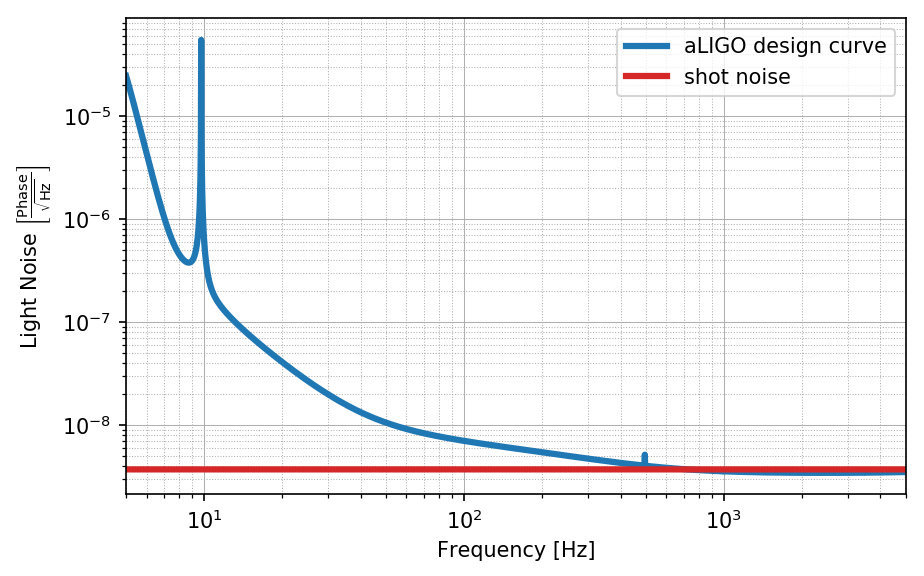

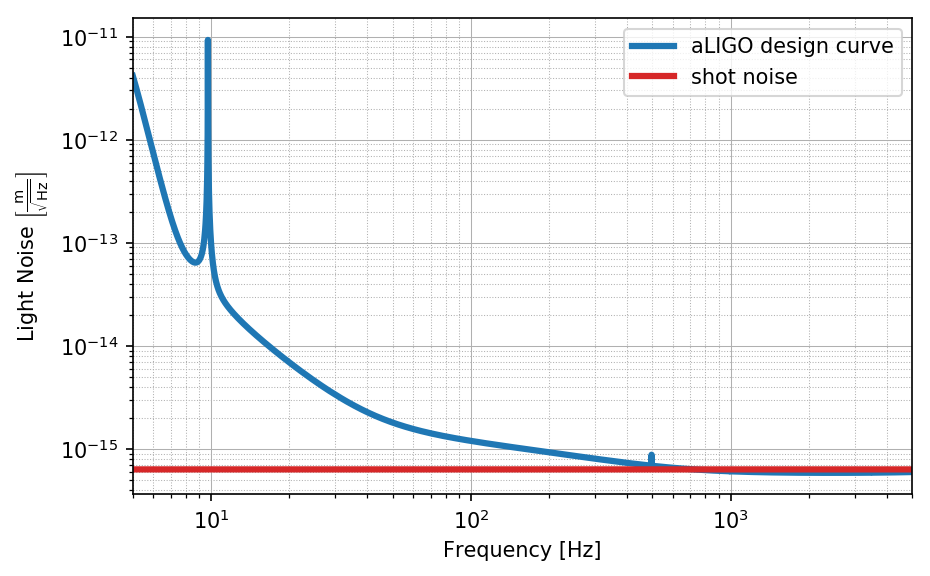

In [14]:
#LO power
LO_power = 98e-3 #100 mW
Sig_power = 5e-3 #1 mW(

power_to_phase = 1/(2*np.sqrt(LO_power*Sig_power))
power_to_distance = wavelength/(2*np.pi)*power_to_phase

plt.loglog(frequency,power_to_phase*aligo_design_curve_light_noise,color = 'tab:blue')
plt.loglog(frequency,power_to_phase*shot_noise,color = 'tab:red')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.autoscale(enable=True, axis='x', tight=True)
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Light Noise $\left[\frac{\rm{Phase}}{\sqrt{\rm{Hz}}}\right]$')
#plt.title('Noise measured on DC OMC photodiode')
plt.legend(['aLIGO design curve','shot noise'])
plt.savefig('light_noise_curve_phase.png',bbox_inches = "tight")
plt.savefig('light_noise_curve_phase.pdf',bbox_inches = "tight")
plt.show()


plt.loglog(frequency,power_to_distance*aligo_design_curve_light_noise,color = 'tab:blue')
plt.loglog(frequency,power_to_distance*shot_noise,color = 'tab:red')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.autoscale(enable=True, axis='x', tight=True)
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Light Noise $\left[\frac{\rm{m}}{\sqrt{\rm{Hz}}}\right]$')
#plt.title('Noise measured on DC OMC photodiode')
plt.legend(['aLIGO design curve','shot noise'])
#plt.savefig('light_noise_curve_m.png',bbox_inches = "tight")
#plt.savefig('light_noise_curve_m.pdf',bbox_inches = "tight")
plt.show()


1.58931475027e-09
2.69135925747e-16


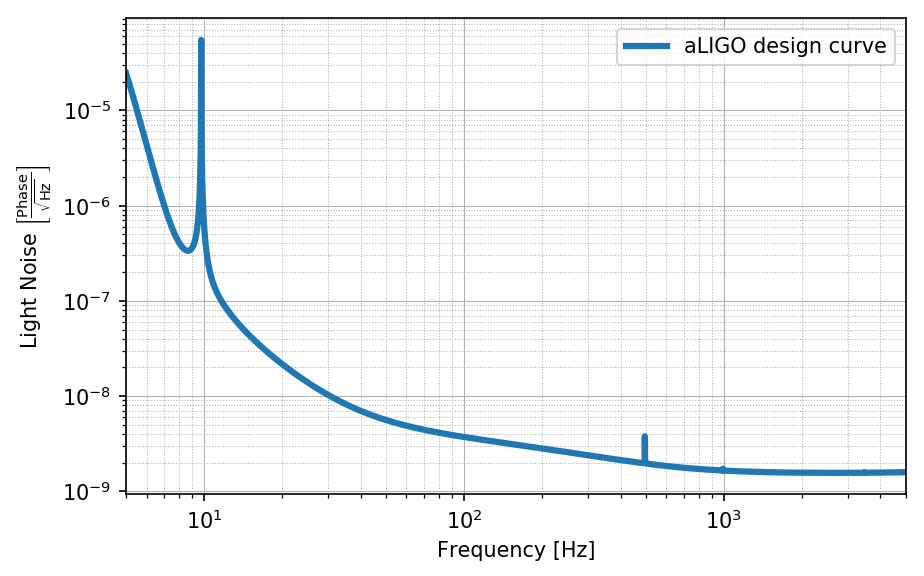

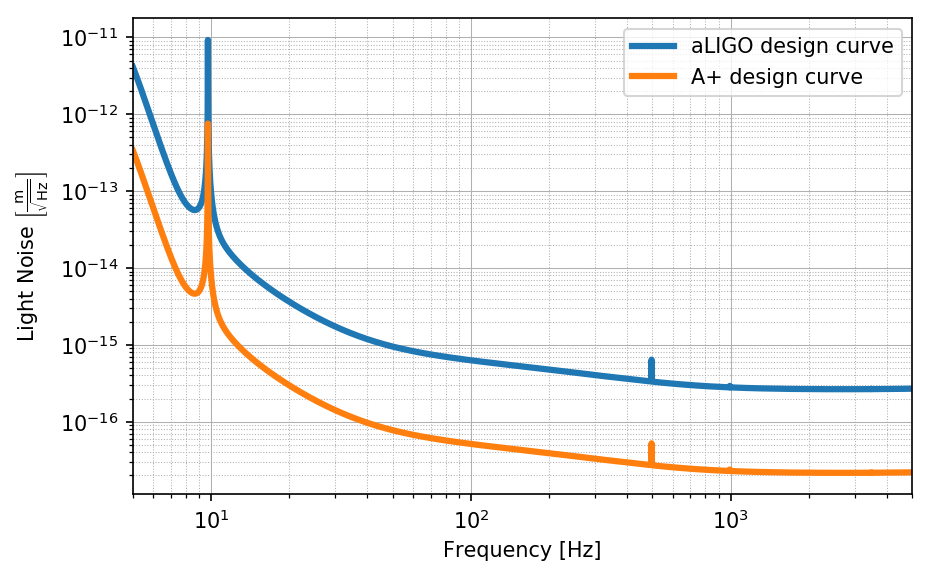

In [15]:
aplus_design = np.loadtxt('AplusDesign.txt')

#input file and finesse simulation use same frequency axis
aplus_design_curve = aplus_design[:,1]


aplus_design_curve_rad = aplus_design_curve*4000*np.pi/(wavelength)
aplus_design_curve_light_noise = aplus_design_curve_rad*response


print(power_to_phase*aplus_design_curve_light_noise[-1])
print(power_to_distance*aplus_design_curve_light_noise[-1])

#plt.loglog(frequency,power_to_phase*aligo_design_curve_light_noise,color = 'tab:blue')
plt.loglog(frequency,power_to_phase*aplus_design_curve_light_noise,color = 'tab:blue')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.autoscale(enable=True, axis='x', tight=True)
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Light Noise $\left[\frac{\rm{Phase}}{\sqrt{\rm{Hz}}}\right]$')
#plt.title('Noise measured on DC OMC photodiode')
plt.legend(['aLIGO design curve','A+ design curve'])
#plt.savefig('aligo_vs_aplus.png',bbox_inches = "tight")
#plt.savefig('aligo_vs_aplus.pdf',bbox_inches = "tight")
plt.show()

#plt.loglog(frequency,power_to_distance*aligo_design_curve_light_noise,color = 'tab:blue')
plt.loglog(frequency,power_to_distance*aplus_design_curve_light_noise,color = 'tab:blue')
plt.loglog(frequency,power_to_distance*aplus_design_curve_light_noise/(10*np.sqrt(3/2)),color = 'tab:orange')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.autoscale(enable=True, axis='x', tight=True)
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Light Noise $\left[\frac{\rm{m}}{\sqrt{\rm{Hz}}}\right]$')
#plt.title('Noise measured on DC OMC photodiode')
plt.legend(['aLIGO design curve','A+ design curve','HRTS motion design equirement'])
#plt.savefig('aligo_vs_aplus_m.png',bbox_inches = "tight")
#plt.savefig('aligo_vs_aplus_m.pdf',bbox_inches = "tight")
plt.show()





# Thesis Plots

response in units of W/h

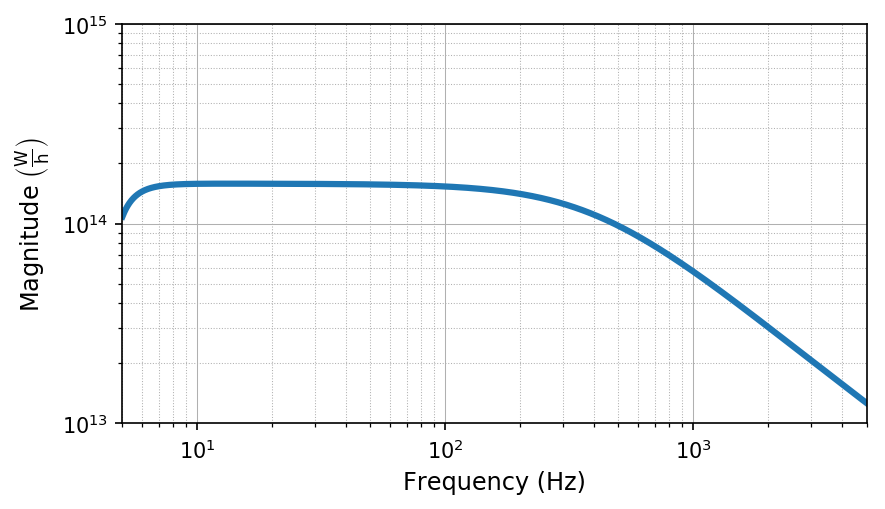

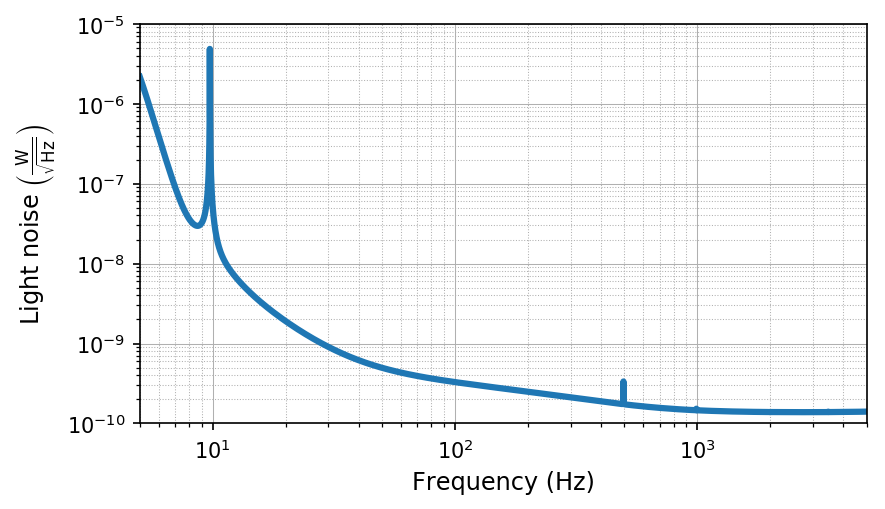

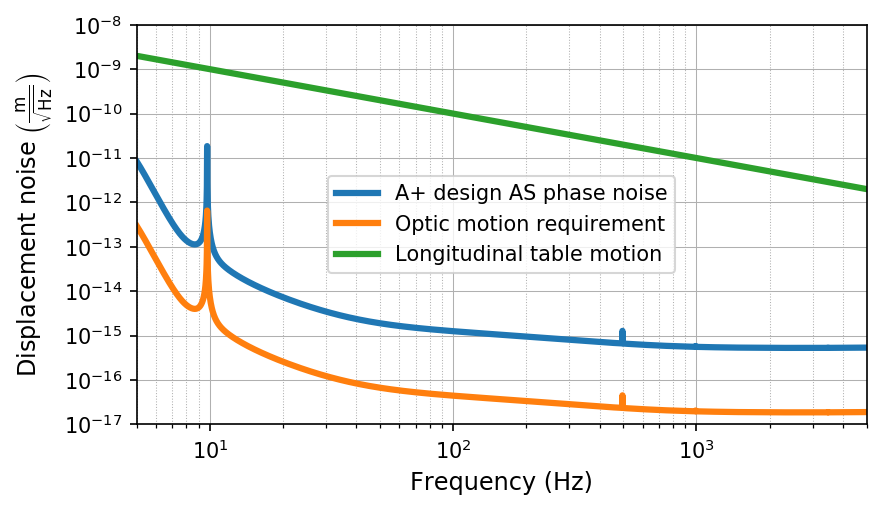

In [16]:
#first 0.5 comes from differential signal
response_w_over_h = 0.5*np.abs(out_LLO['P_DC_OMC_probe'])/(1064e-9/(2*np.pi*4000))

xlim = [10,5000]
fontsize = 11.5
linewidth = 3

plt.figure(figsize = (6,3.5),dpi = 150)
plt.loglog(out_LLO.x,response_w_over_h,linewidth = linewidth)
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.ylabel(r'Magnitude $\left(\frac{\rm{W}}{\rm{h}}\right)$',fontsize = fontsize)
plt.xlabel('Frequency (Hz)',fontsize = fontsize)
plt.xlim([5,5000])
plt.ylim([1e13,1e15])
plt.tight_layout()
plt.savefig('BHD_for_ligo_chapter_detector_repsonse.eps')
plt.show()


light_noise_req = aplus_design_curve*response_w_over_h

plt.figure(figsize = (6,3.5),dpi = 150)
plt.loglog(out_LLO.x,light_noise_req,linewidth = linewidth)
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.ylabel(r'Light noise $\left(\frac{\rm{W}}{\sqrt{\rm{Hz}}}\right)$',fontsize = fontsize)
plt.xlabel('Frequency (Hz)',fontsize = fontsize)
plt.xlim([5,5000])
plt.ylim([1e-10,1e-5])
plt.tight_layout()
plt.savefig('BHD_for_ligo_chapter_light_noise.eps')
plt.show()

LO_path_req = light_noise_req*1064e-9/(2*np.pi)/(2*np.sqrt(5e-3*98e-3))
model_noise = 10e-10*10/(out_LLO.x)

num_of_mirrors = 2
#plus 2 for the recombination beam splitter
plt.figure(figsize = (6,3.5),dpi = 150)
plt.loglog(out_LLO.x,LO_path_req,linewidth = linewidth,label = 'A+ design AS phase noise')
#plt.loglog(out_LLO.x,LO_path_req/(10*np.sqrt((2+num_of_mirrors)/2)),linewidth = linewidth, label = 'Optic motion requirement')
plt.loglog(out_LLO.x,LO_path_req/(10*np.sqrt(8)),linewidth = linewidth, label = 'Optic motion requirement')
plt.loglog(out_LLO.x,model_noise,linewidth = linewidth, label = 'Longitudinal table motion')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.ylabel(r'Displacement noise $\left(\frac{\rm{m}}{\sqrt{\rm{Hz}}}\right)$',fontsize = fontsize)
plt.xlabel('Frequency (Hz)',fontsize = fontsize)
plt.xlim([5,5000])
plt.legend(prop = {'size':10})
plt.ylim([1e-17,1e-8])
plt.yticks(np.logspace(-17,-8,17-8+1))
plt.tight_layout()
plt.savefig('BHD_for_ligo_chapter_HRTS_requirement.eps')
plt.show()

In [17]:
print(LO_path_req[-1]/(10*np.sqrt(8)))

1.90307838157e-17


In [18]:
print(LO_path_req[0]/(10*np.sqrt(8)))


2.93614202991e-13


In [19]:
(2+num_of_mirrors)/2

2.0

In [20]:
print(np.sqrt(2*6.63e-34*3e8*1064e-9/(16*np.pi**2*5e-3))/np.sqrt(2)) 


response_w_over_h_test = 0.5*np.abs(out_LLO['P_DC_OMC_probe'])/(1064e-9/(2*np.pi*4000))
light_noise_req_test = aplus_design_curve*response_w_over_h_test

LO_path_req_test = light_noise_req_test*1064e-9/(2*np.pi)/(2*np.sqrt(5e-3*98e-3))
print(LO_path_req_test[-1])



5.17718088898e-16
5.38271851494e-16


In [21]:
model_noise[0]

2.0000000000000001e-09

# relationship between shot noise and phase uncertainty

from the HUP, the relationship between phase, $\phi$, and photon number, $N$, is
$$4(\Delta\phi)^2 \geq 1/N. $$

So,
$$\Delta\phi \geq \frac{1}{\sqrt{4N}}. $$

Add in squeezing, $\xi $,
$$\Delta\phi \geq \frac{1}{\sqrt{4N}}\xi$$

and substitute $N$ for power, $P$ with
$$N = \frac{P}{h\nu}, $$

where $h$ is Planck's constant and $\nu$ is the frequency of the light. This gives
$$
\Delta\phi = \sqrt{\frac{h\nu}{4P}}\xi.
$$
\par
The strain sensitivity curve, $S(h)$, is to do with signals in the arm, so the linear response function of the arm cavities needs applying
$$
G(f) = \frac{G_0}{1 - if/(380\rm{Hz})}.
$$

The gain factor $G_0$, in units of phase/strain, can be found by making a region of the $S\times G$ that is dominated by shot noise equal to $\Delta \phi$. __However__, as the strain sensitivity curve already includes the squeezing, you actually don't need $\xi$.

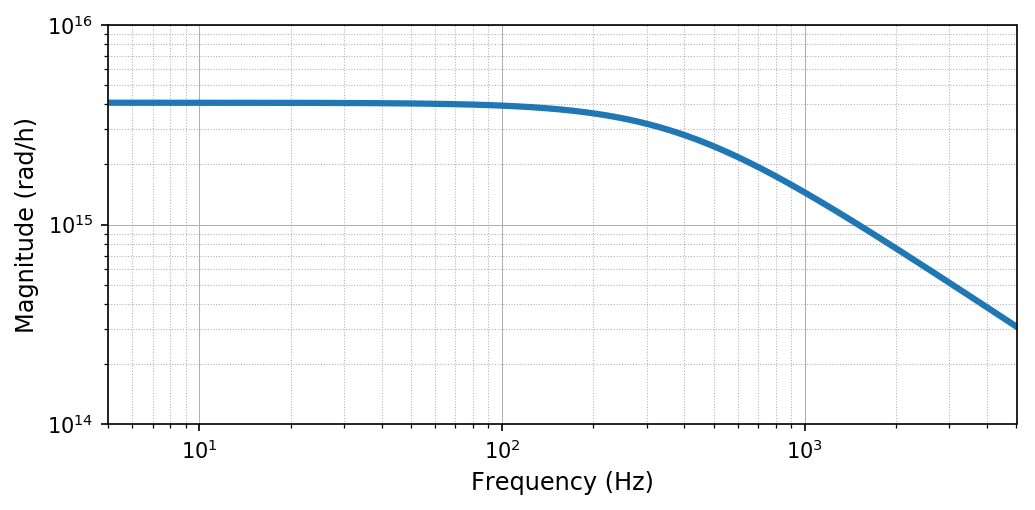

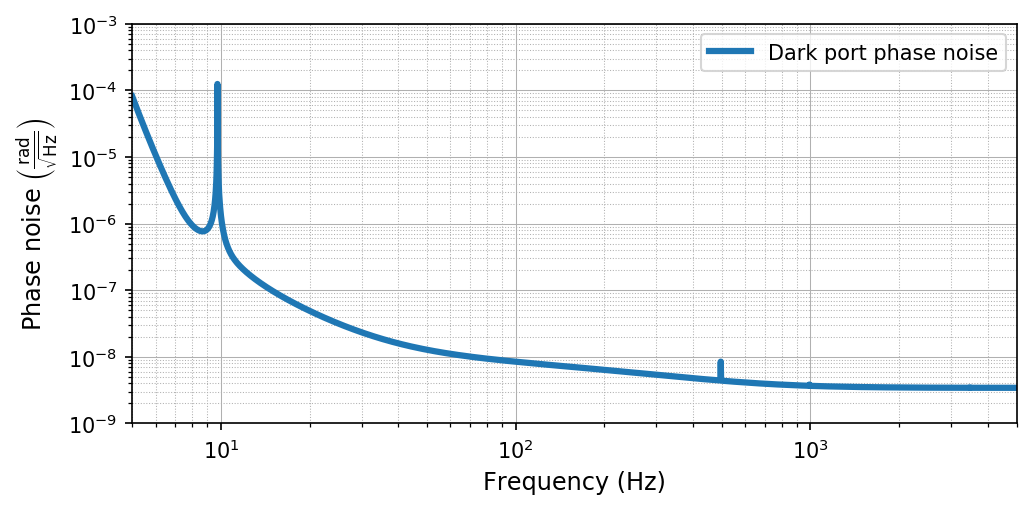

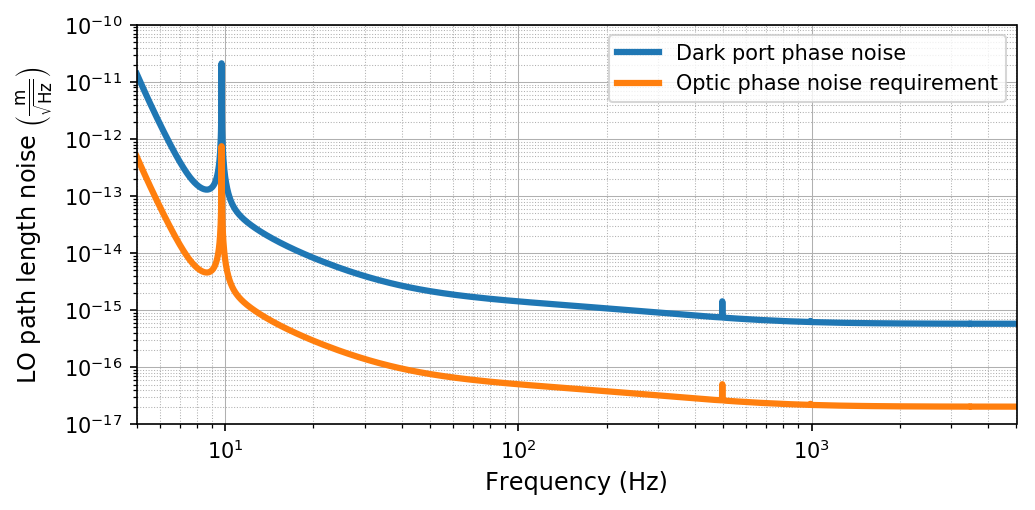

In [40]:
#f = np.logspace(1,4,1000)

#method 1
#frequency =  np.logspace(1,4,1000)
#frequency = np.logspace(np.log10(5),np.log10(5000),2999)
#aplus_design = np.loadtxt('AplusDesign.txt')
#aplus_design_curve = aplus_design[:,1]

f_corner = 380;
toy_model = 1/(1 - 1j*frequency/f_corner)
h = 6.63e-34
v = 3e8/1064e-9

squeezing = 0 # dB
shot_noise_light = np.sqrt(2*h*v*105e-3)/10**(squeezing/20)

#factor = shot_noise_light/(aplus_design_curve[-1]*np.abs(toy_model[-1]))
#light_noise_to_phase_factor = 1/(2*np.sqrt(5e-3*100e-3))

# method 2

sig_power = 5e-3;
factor_of_2 = 2;
delta_phi = np.sqrt((h*v)/(factor_of_2**2*sig_power))*10**(1/20)

factor = delta_phi/(aplus_design_curve[-1]*np.abs(toy_model[-1]))
light_noise_to_phase_factor = 1

plt.figure(figsize = (7,3.5),dpi = 150)
plt.loglog(frequency,factor*np.abs(toy_model))
#plt.loglog(out_LLO.x,response_w_over_h,linewidth = linewidth,label = 'Finesse')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.ylabel(r'Magnitude (rad/h)',fontsize = fontsize)
plt.xlabel('Frequency (Hz)',fontsize = fontsize)
plt.xlim([5,5000])
plt.ylim([1e14,1e16])
plt.tight_layout()
plt.savefig('BHD_for_ligo_chapter_detector_repsonse.eps')
plt.show()

#plt.loglog(frequency,np.abs(toy_model))
plt.figure(figsize = (7,3.5),dpi = 150)
plt.loglog(frequency,light_noise_to_phase_factor*factor*aplus_design_curve*np.abs(toy_model),label = 'Dark port phase noise')
#plt.axhline(light_noise_to_phase_factor*shot_noise_light,color = 'tab:red',label = '100mW shot noise')
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.ylabel(r'Phase noise $\left(\frac{\rm{rad}}{\sqrt{\rm{Hz}}}\right)$',fontsize = fontsize)
plt.xlabel('Frequency (Hz)',fontsize = fontsize)
plt.legend(prop = {'size':10})
plt.xlim([5,5000])
plt.ylim([1e-9,1e-3])
plt.tight_layout()
plt.savefig('BHD_for_ligo_chapter_phase_noise.eps')
plt.show()

phase_factor_to_distance = 1064e-9/(2*np.pi)
LIGO_factor = 10*np.sqrt(8) # 10 = safety factor, sqrt(8) = optics at 45 deg, 2 mirrors and 1 BS (double count the BS).

AS_noise = phase_factor_to_distance*light_noise_to_phase_factor*factor*aplus_design_curve*np.abs(toy_model)
optic_req = phase_factor_to_distance*light_noise_to_phase_factor*factor*aplus_design_curve*np.abs(toy_model)/LIGO_factor
table_model_noise = 10e-10*10/(frequency)
shot_noise_metres = phase_factor_to_distance*light_noise_to_phase_factor*shot_noise_light

plt.figure(figsize = (7,3.5),dpi = 150)
plt.loglog(frequency,AS_noise,label = 'Dark port phase noise')
plt.loglog(frequency,optic_req,label = 'Optic phase noise requirement')
#plt.axhline(shot_noise_metres,color = 'tab:red',label = '100mW shot noise')
#plt.loglog(frequency,table_model_noise,linewidth = linewidth, label = 'Longitudinal table motion')
#plt.ylabel(r'LO path length noise $\left(\rm{\frac{m/\sqrt{Hz}}}\right)$',fontsize = fontsize)
plt.ylabel(r'LO path length noise $\left(\frac{\rm{m}}{\sqrt{\rm{Hz}}}\right)$',fontsize = fontsize)
plt.xlabel('Frequency (Hz)',fontsize = fontsize)
plt.xlim([5,5000])
plt.ylim([1e-17,1e-11])
plt.yticks(np.logspace(-17,-10,18-11+1))
plt.grid(b=True, which='major' , linestyle='-')
plt.grid(b=True, which='minor', linestyle=':')
plt.minorticks_on()
plt.tight_layout()
plt.legend(prop = {'size':10})
plt.savefig('BHD_for_ligo_chapter_HRTS_requirement.eps')
plt.show()



In [ ]:
print(optic_req[-1])
print(optic_req[0])

print(light_noise_to_phase_factor*factor*aplus_design_curve[-1]*np.abs(toy_model[-1]))
print(light_noise_to_phase_factor*factor*aplus_design_curve[0]*np.abs(toy_model[0]))

In [ ]:
1.1e-9*np.sqrt(5)